In [1]:
from pathlib import Path
import os
import sys

_here = Path.cwd().resolve()
_candidates = [_here, *_here.parents]
PROJECT_ROOT = next(
    path for path in _candidates
    if (path / "pyproject.toml").exists() and (path / "src" / "us_gdp_regime").exists()
)
os.chdir(PROJECT_ROOT)
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

In [2]:
from __future__ import annotations

from pathlib import Path
from typing import Iterable

import pandas as pd
from IPython.display import HTML, Image, Markdown, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

CSS = """
<style>
:root { --ink:#17202A; --muted:#5D6D7E; --line:#DDE3EA; --blue:#2457A6; --green:#168A60; --red:#B23B3B; --gold:#C49A21; --bg:#FBFCFE; }
.nb-hero { border-left: 7px solid var(--blue); padding: 18px 22px; background: linear-gradient(90deg,#F3F7FD,#FFFFFF); margin: 8px 0 18px 0; }
.nb-hero h1 { margin: 0 0 6px 0; font-size: 30px; color: var(--ink); }
.nb-hero p { margin: 0; color: var(--muted); font-size: 15px; }
.nb-callout { border:1px solid var(--line); border-left:5px solid var(--gold); border-radius:8px; background:#fffdf5; padding:14px 16px; margin:12px 0; color:var(--ink); }
.nb-grid { display:grid; grid-template-columns: repeat(auto-fit, minmax(170px, 1fr)); gap:12px; margin:14px 0 18px; }
.nb-card { border:1px solid var(--line); border-radius:10px; background:var(--bg); padding:14px 16px; }
.nb-card .label { color:var(--muted); font-size:12px; text-transform:uppercase; letter-spacing:.04em; }
.nb-card .value { color:var(--ink); font-size:24px; font-weight:800; line-height:1.15; margin-top:4px; }
.nb-card .note { color:var(--muted); font-size:12px; margin-top:4px; }
.nb-section { margin-top: 18px; }
.nb-section h2 { color:var(--ink); border-bottom:1px solid var(--line); padding-bottom:7px; }
.nb-small { color:var(--muted); font-size: 13px; }
</style>
"""
display(HTML(CSS))


def hero(title: str, subtitle: str) -> None:
    display(HTML(f'<div class="nb-hero"><h1>{title}</h1><p>{subtitle}</p></div>'))


def callout(title: str, body: str) -> None:
    display(HTML(f'<div class="nb-callout"><strong>{title}</strong><br>{body}</div>'))


def metric_cards(cards: Iterable[tuple[str, str, str]]) -> None:
    html = '<div class="nb-grid">'
    for label, value, note in cards:
        html += f'<div class="nb-card"><div class="label">{label}</div><div class="value">{value}</div><div class="note">{note}</div></div>'
    html += '</div>'
    display(HTML(html))


def output_manifest(outputs: dict[str, Path] | dict[str, object]) -> pd.DataFrame:
    rows = []
    for name, path in outputs.items():
        p = Path(path)
        rows.append({"output": name, "path": str(p), "exists": p.exists()})
    return pd.DataFrame(rows)


def show_png(path: Path, width: int = 1200) -> None:
    display(Image(filename=str(path), width=width))

In [3]:
hero(
    "01 | Data extraction and validation",
    "Build the 1920-onward U.S. real GDP series, audit the transformation, and compare Maddison with FRED/BEA where they overlap.",
)

## Why this notebook exists

A regime analysis is only useful if the underlying series is coherent. This notebook answers four practical questions before any modelling happens:

1. Can the Maddison 2023 workbook be parsed reproducibly?
2. Does the constructed real GDP proxy have the expected annual structure?
3. Are growth rates calculated consistently from the level series?
4. Where FRED/BEA overlaps, do the two growth series move closely enough for validation?

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd

from us_gdp_regime.config import load_config
from us_gdp_regime.pipeline import prepare_data
from us_gdp_regime.plotting import plot_annual_growth_overview

config = load_config(Path("config/default.yaml"))
outputs = prepare_data(config)
series = pd.read_csv(outputs["series"])
series_nonmissing = series.dropna(subset=["gdp_growth"]).copy()

validation_summary_path = config.paths.models_dir / "source_validation_summary.csv"
validation_summary = (
    pd.read_csv(validation_summary_path) if validation_summary_path.exists() else pd.DataFrame()
)

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [5]:
cards = [
    ("Coverage", f"{int(series['year'].min())}-{int(series['year'].max())}", "Annual observations"),
    ("Observations", f"{len(series):,}", "Prepared Maddison rows"),
    ("Mean growth", f"{series_nonmissing['gdp_growth'].mean():.2f}%", "Full sample, first growth year onward"),
    ("Growth volatility", f"{series_nonmissing['gdp_growth'].std():.2f} pp", "Standard deviation"),
]
if not validation_summary.empty:
    row = validation_summary.iloc[0]
    cards.extend([
        ("FRED overlap", f"{int(row['start_year'])}-{int(row['end_year'])}", f"{int(row['n_overlap_years'])} years"),
        ("Source correlation", f"{row['growth_correlation']:.3f}", "Maddison vs FRED growth"),
    ])
metric_cards(cards)
callout(
    "Reading guide",
    "The first chart shows annual growth from the prepared Maddison series. The tables below audit missingness, calculation consistency, and source overlap. Differences with FRED/BEA are validation diagnostics, not corrections to the Maddison historical series.",
)

## Source design

**Primary source:** Maddison Project Database 2023. GDP per capita and population are multiplied to construct a long-run real GDP proxy from 1920 onward.

**Validation source:** FRED/BEA `GDPCA`. This is the modern annual real GDP benchmark from 1929 onward, so it is used for overlap diagnostics rather than as the default 1920-onward source.

The scale of the Maddison-derived GDP proxy depends on source units, but annual growth rates and log-trend timing are invariant to constant unit rescaling.

## Prepared series preview

In [6]:
display(
    series.head(8).style.format(
        {
            "real_gdp": "{:,.0f}",
            "gdp_growth": "{:.2f}",
            "real_gdp_per_capita": "{:,.0f}",
            "population": "{:,.0f}",
            "log_real_gdp": "{:.3f}",
        },
        na_rep="",
    )
)

,year,real_gdp,gdp_growth,real_gdp_per_capita,population,source,log_real_gdp
0,1920,"1,085,155,002",,"10,153","106,881",maddison_2023,20.805
1,1921,"1,054,213,677",-2.85,"9,675","108,964",maddison_2023,20.776
2,1922,"1,105,913,383",4.90,"10,010","110,484",maddison_2023,20.824
3,1923,"1,244,263,785",12.51,"11,071","112,387",maddison_2023,20.942
4,1924,"1,274,653,986",2.44,"11,127","114,558",maddison_2023,20.966
5,1925,"1,296,540,090",1.72,"11,150","116,284",maddison_2023,20.983
6,1926,"1,372,770,967",5.88,"11,648","117,857",maddison_2023,21.040
7,1927,"1,378,144,614",0.39,"11,532","119,502",maddison_2023,21.044


## Data dictionary

The table below keeps definitions close to the actual output columns, which makes the notebook easier to review and reproduce.

In [7]:
dictionary = pd.DataFrame(
    {
        "variable": ["year", "real_gdp", "gdp_growth", "real_gdp_per_capita", "population", "source", "log_real_gdp"],
        "definition": [
            "Calendar year",
            "Maddison-derived real GDP proxy",
            "Annual percent change in real GDP",
            "Maddison real GDP per capita estimate",
            "Maddison population estimate",
            "Source identifier",
            "Natural log of the real GDP proxy",
        ],
        "used_for": [
            "time index",
            "trend and growth calculation",
            "regime modelling",
            "source construction",
            "source construction",
            "provenance",
            "trend regression",
        ],
    }
)
display(dictionary.style.hide(axis="index"))

variable,definition,used_for
year,Calendar year,time index
real_gdp,Maddison-derived real GDP proxy,trend and growth calculation
gdp_growth,Annual percent change in real GDP,regime modelling
real_gdp_per_capita,Maddison real GDP per capita estimate,source construction
population,Maddison population estimate,source construction
source,Source identifier,provenance
log_real_gdp,Natural log of the real GDP proxy,trend regression


## Missingness and calculation audit

In [8]:
missing = series.isna().sum().rename("missing_values").to_frame()
missing["share"] = missing["missing_values"] / len(series)
display(missing.style.format({"share": "{:.1%}"}))

check = series[["year", "real_gdp", "gdp_growth"]].copy()
check["computed_growth"] = check["real_gdp"].pct_change() * 100
check["difference"] = check["gdp_growth"] - check["computed_growth"]
max_abs_diff = check["difference"].abs().dropna().max()
metric_cards([("Max growth audit gap", f"{max_abs_diff:.6f} pp", "Stored growth vs recomputed growth")])
display(check.head(10).style.format({"real_gdp": "{:,.0f}", "gdp_growth": "{:.3f}", "computed_growth": "{:.3f}", "difference": "{:.6f}"}, na_rep=""))

,missing_values,share
year,0,0.0%
real_gdp,0,0.0%
gdp_growth,1,1.0%
real_gdp_per_capita,0,0.0%
population,0,0.0%
source,0,0.0%
log_real_gdp,0,0.0%


,year,real_gdp,gdp_growth,computed_growth,difference
0,1920,"1,085,155,002",,,
1,1921,"1,054,213,677",-2.851,-2.851,-0.000000
2,1922,"1,105,913,383",4.904,4.904,0.000000
3,1923,"1,244,263,785",12.510,12.510,0.000000
4,1924,"1,274,653,986",2.442,2.442,0.000000
5,1925,"1,296,540,090",1.717,1.717,0.000000
6,1926,"1,372,770,967",5.880,5.880,0.000000
7,1927,"1,378,144,614",0.391,0.391,-0.000000
8,1928,"1,385,247,263",0.515,0.515,0.000000
9,1929,"1,461,345,500",5.493,5.493,-0.000000


## Annual growth profile

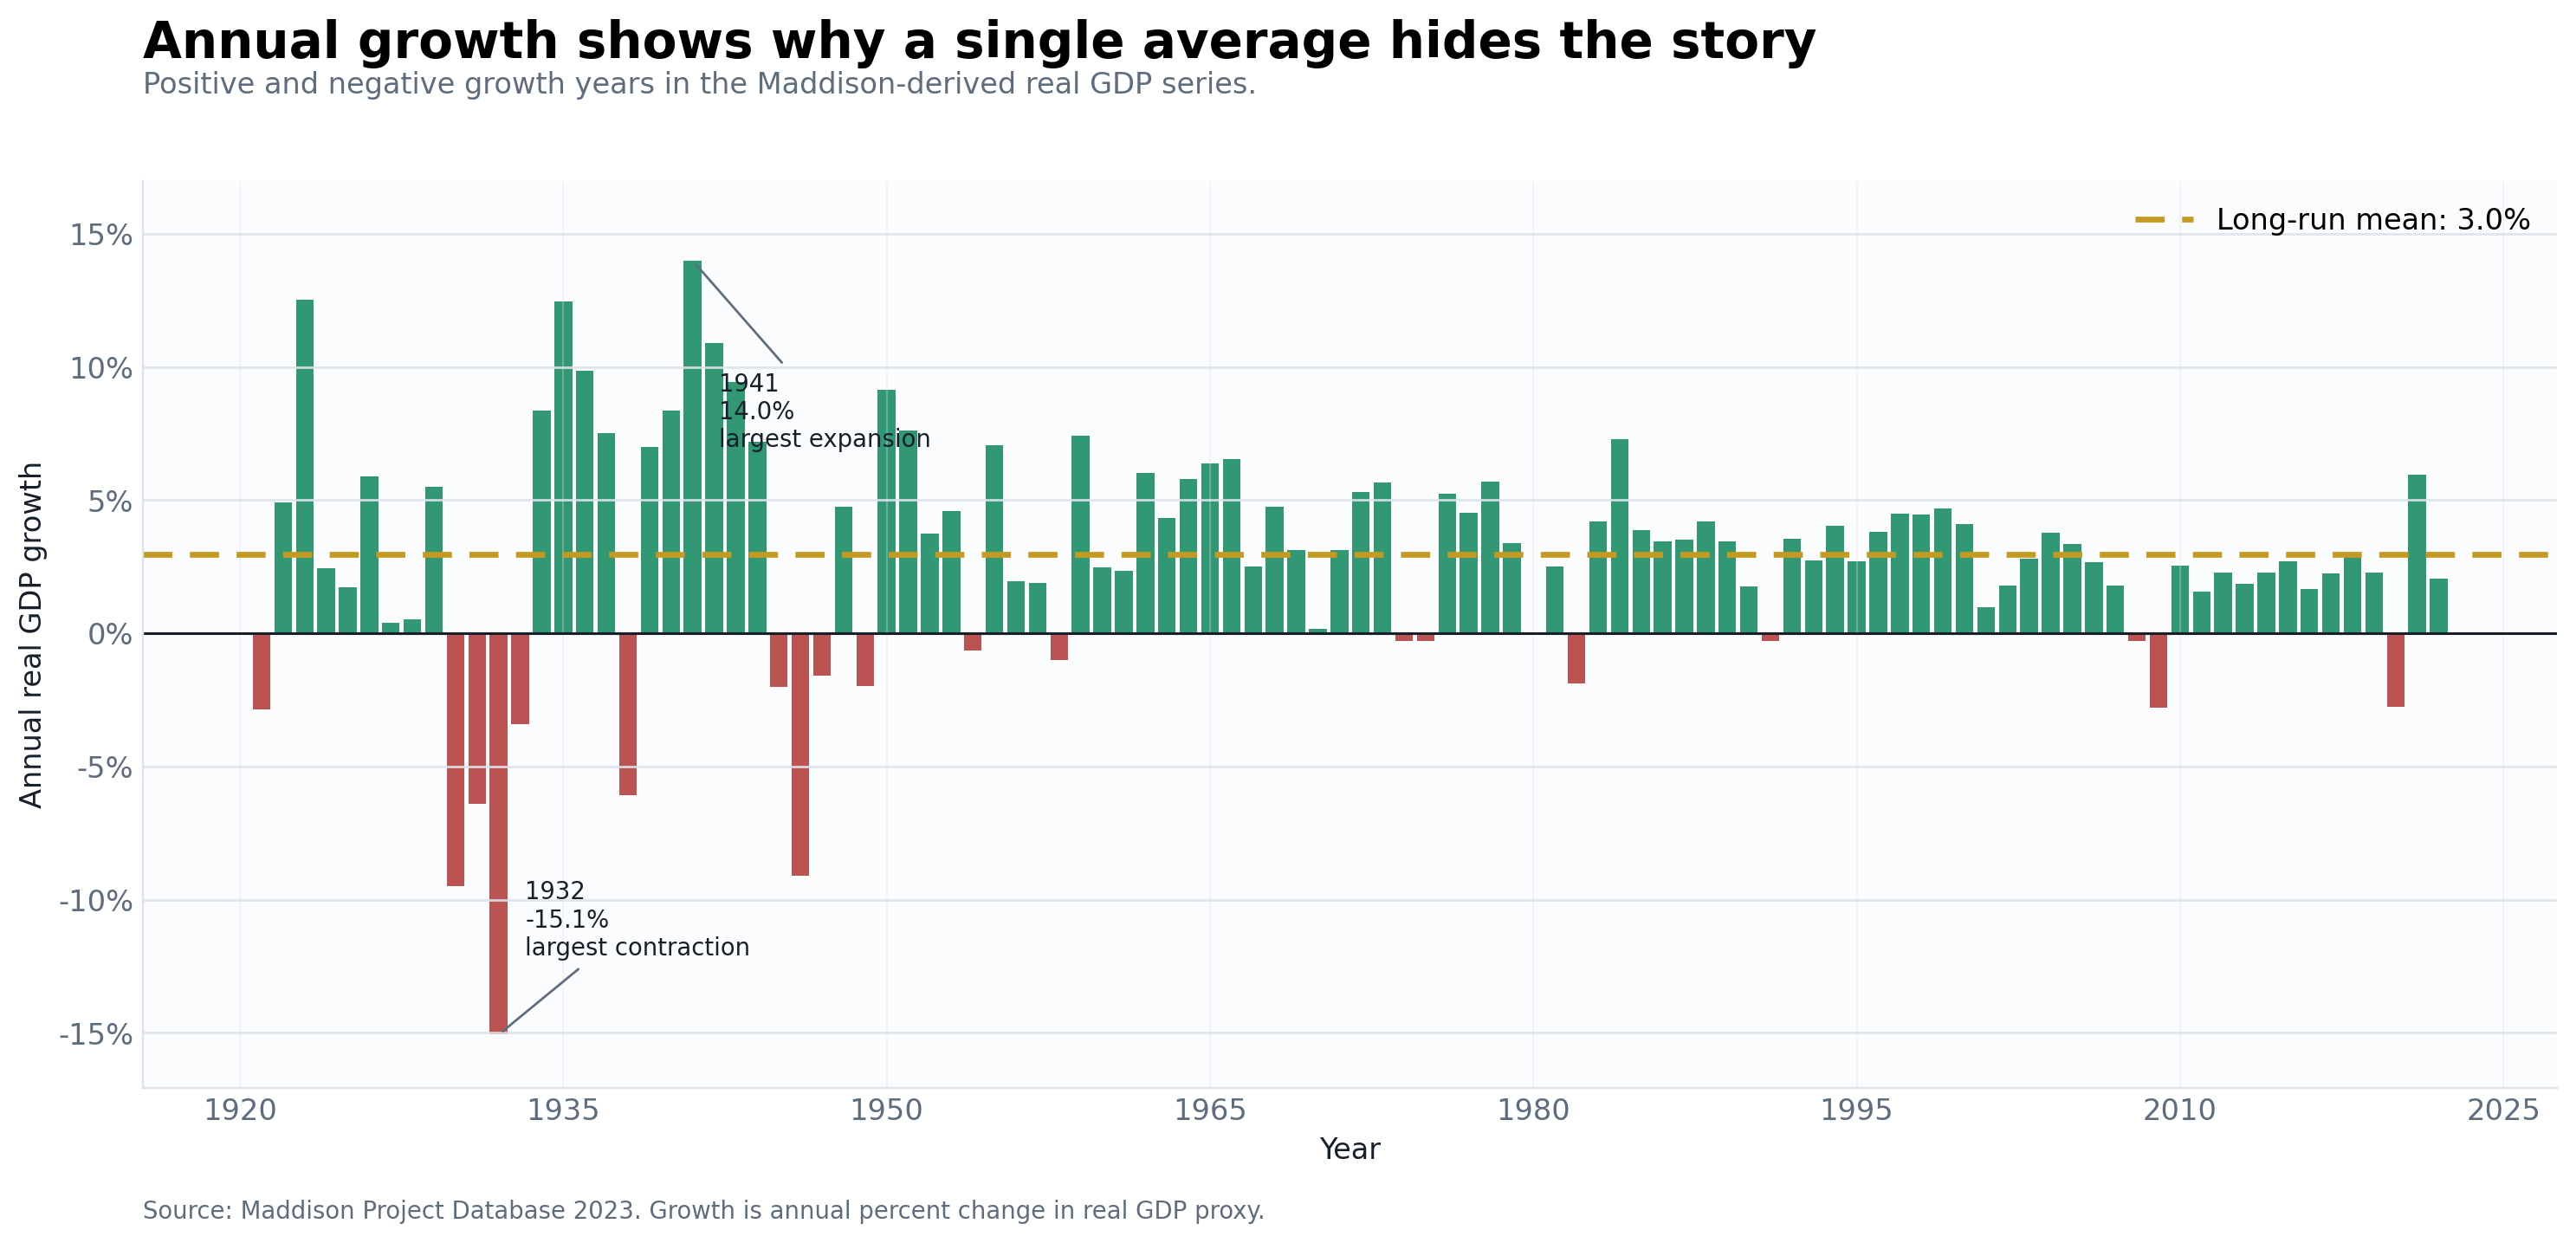

In [9]:
growth_overview_path = config.paths.figures_dir / "annual_growth_overview.png"
plot_annual_growth_overview(series, growth_overview_path, dpi=config.plots.dpi)
show_png(growth_overview_path, width=1250)

## Maddison versus FRED/BEA overlap diagnostics

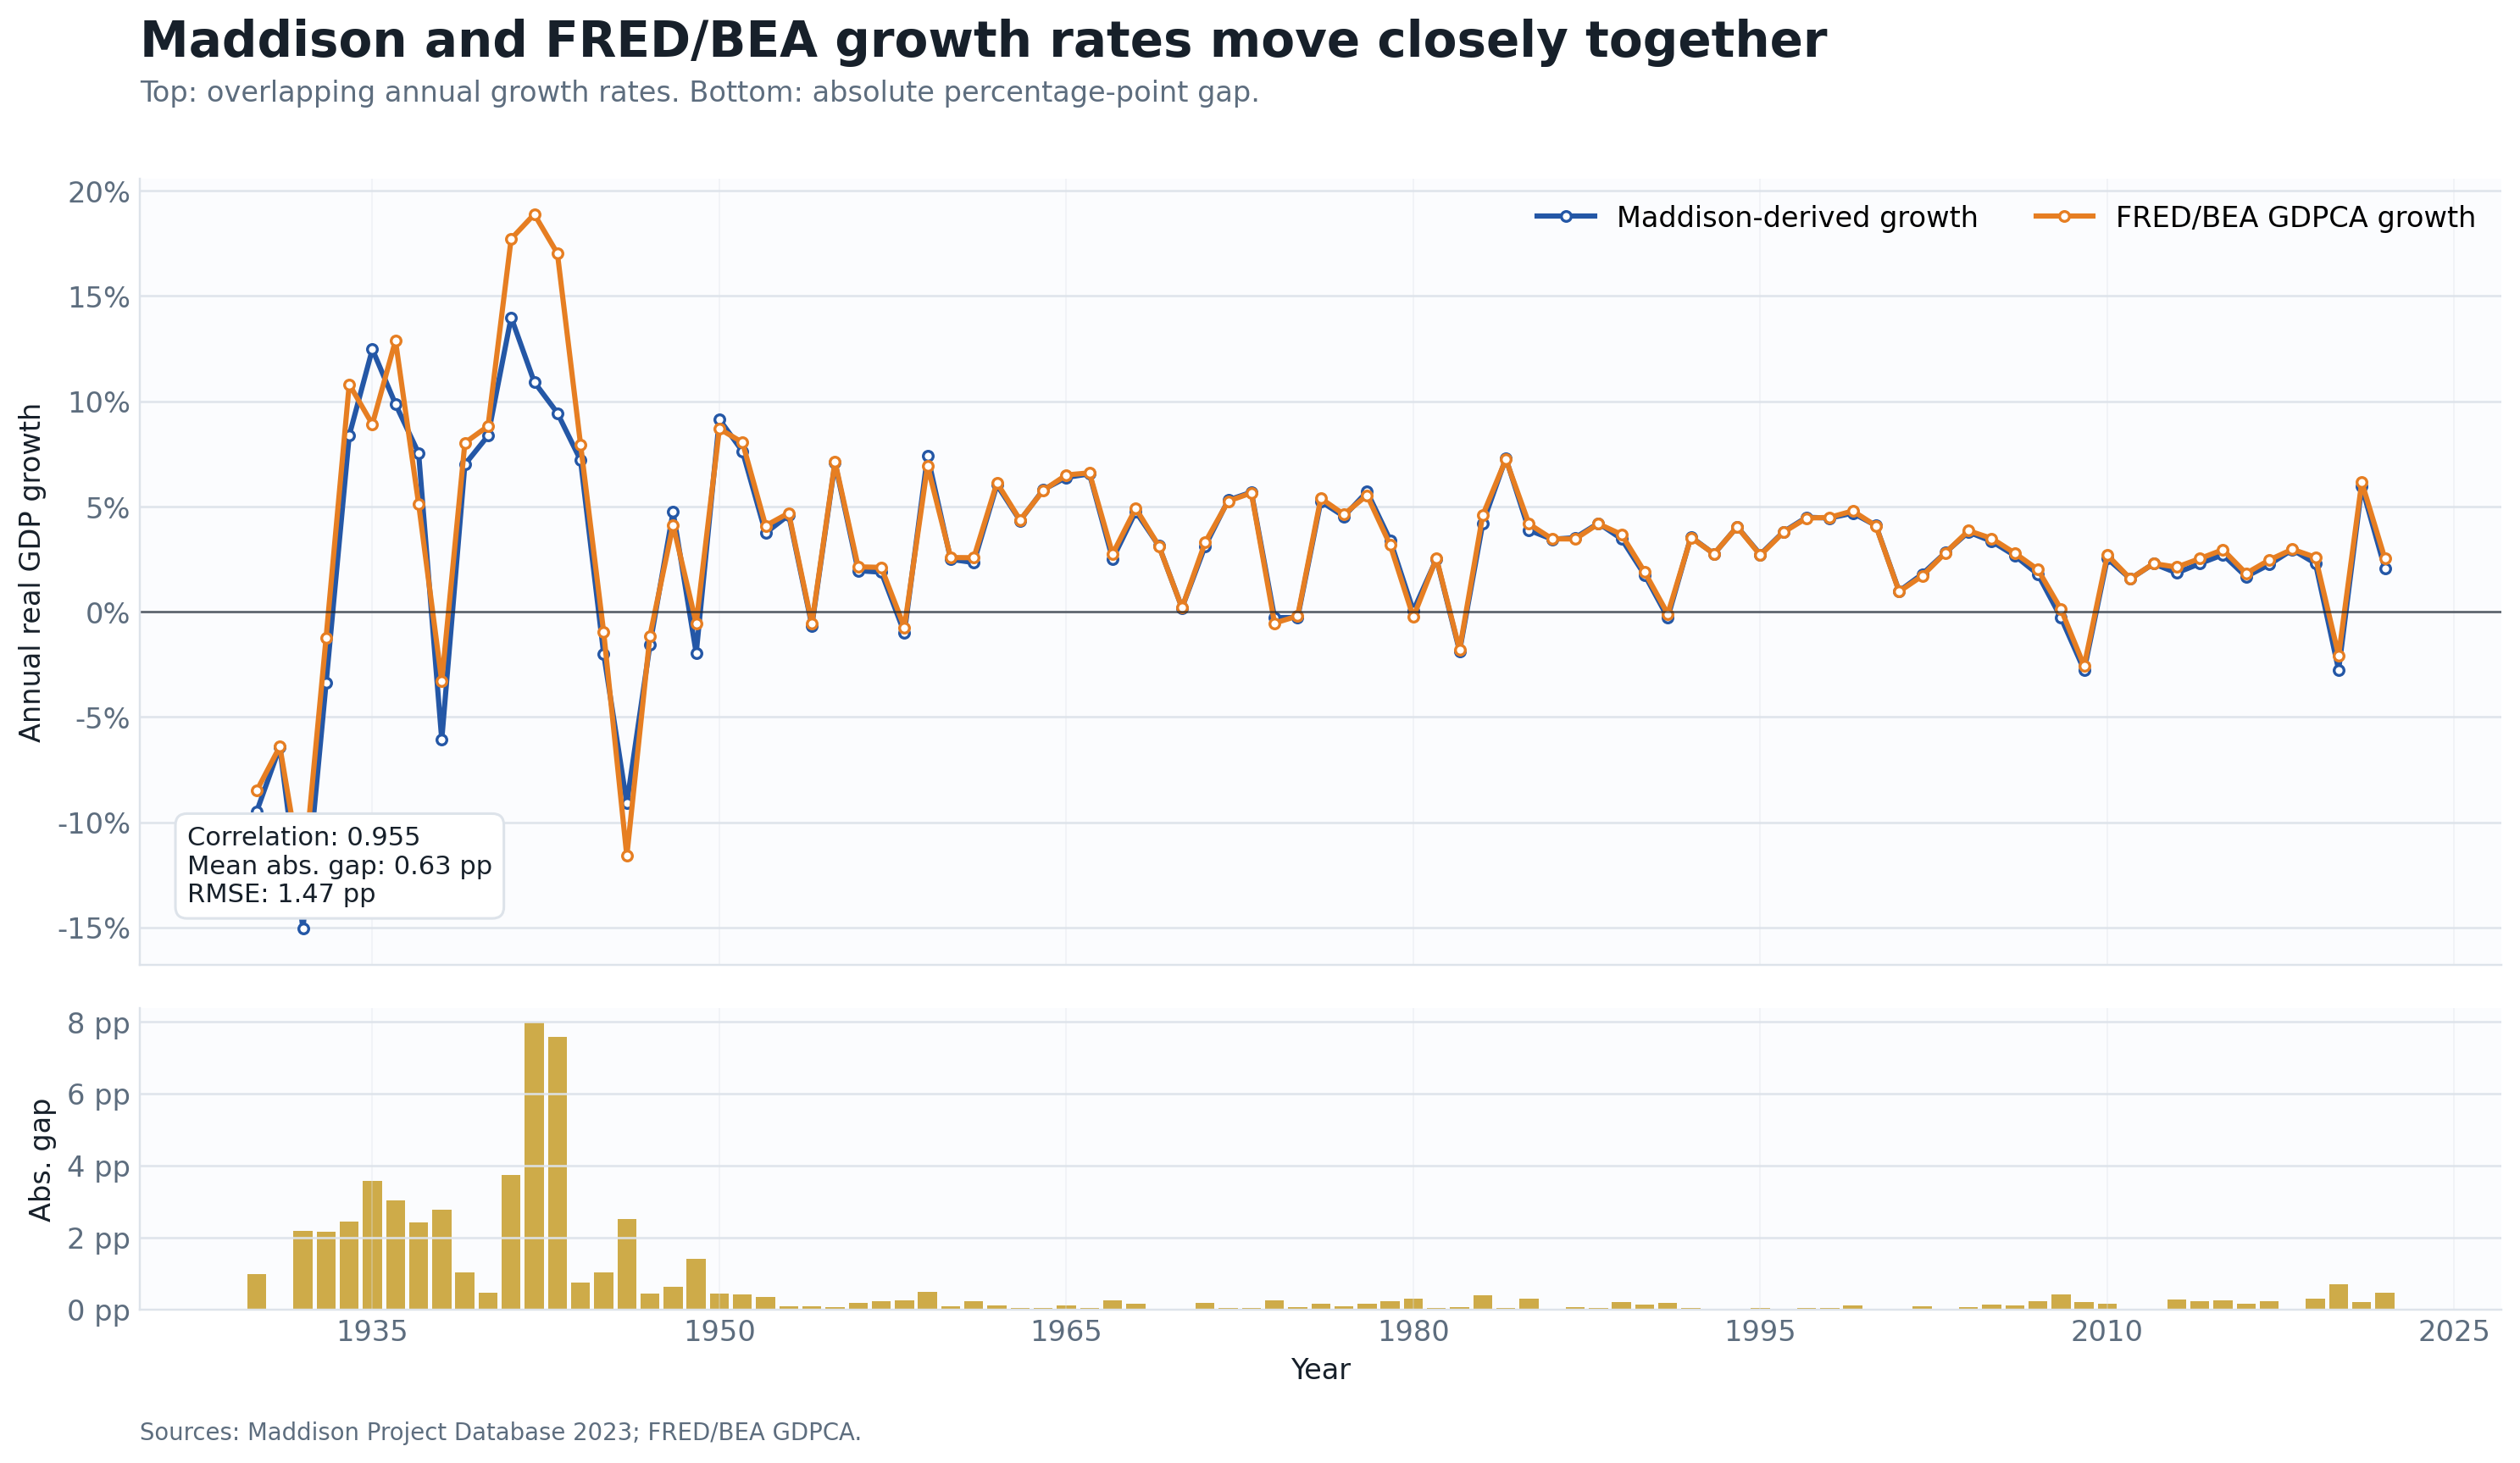

,year,growth_maddison,growth_fred,growth_difference,abs_growth_difference
0,1942,10.91,18.89,-7.97,7.97
1,1943,9.44,17.02,-7.58,7.58
2,1941,13.99,17.71,-3.72,3.72
3,1935,12.47,8.90,3.57,3.57
4,1936,9.87,12.88,-3.02,3.02
5,1938,-6.08,-3.31,-2.77,2.77
6,1946,-9.11,-11.61,2.50,2.50
7,1934,8.37,10.81,-2.44,2.44
8,1937,7.53,5.12,2.41,2.41
9,1932,-15.07,-12.90,-2.17,2.17


In [10]:
comparison_path = config.paths.models_dir / "fred_maddison_growth_comparison.csv"
largest_path = config.paths.models_dir / "source_validation_largest_differences.csv"
comparison_figure_path = config.paths.figures_dir / "fred_maddison_growth_comparison.png"

if comparison_path.exists():
    comparison = pd.read_csv(comparison_path)
    largest = pd.read_csv(largest_path)
    row = validation_summary.iloc[0]
    metric_cards([
        ("Overlap years", f"{int(row['n_overlap_years'])}", f"{int(row['start_year'])}-{int(row['end_year'])}"),
        ("Correlation", f"{row['growth_correlation']:.3f}", "annual growth rates"),
        ("Mean abs. gap", f"{row['mean_absolute_difference']:.2f} pp", "percentage-point difference"),
        ("RMSE", f"{row['root_mean_squared_difference']:.2f} pp", "percentage-point difference"),
    ])
    show_png(comparison_figure_path, width=1250)
    display(
        largest.head(10).style.format(
            {
                "growth_maddison": "{:.2f}",
                "growth_fred": "{:.2f}",
                "growth_difference": "{:.2f}",
                "abs_growth_difference": "{:.2f}",
            }
        )
    )
else:
    callout("Validation skipped", "No local FRED/BEA CSV was available. The Maddison series was still prepared.")

## Output manifest

In [11]:
display(output_manifest(outputs).style.hide(axis="index"))

output,path,exists
series,data\processed\us_gdp_series.csv,True
fred_comparison,data\models\fred_maddison_growth_comparison.csv,True
source_validation_summary,data\models\source_validation_summary.csv,True
source_validation_largest_differences,data\models\source_validation_largest_differences.csv,True
fred_comparison_figure,figures\fred_maddison_growth_comparison.png,True


## Notebook conclusion

The prepared Maddison series is complete for the target 1920-onward window after the initial growth-rate gap. Growth-rate recomputation matches the stored values. Where FRED/BEA is available, the overlap diagnostics provide a separate check on modern national-account consistency. The next notebook uses the prepared Maddison series for trend and regime modelling.